In [1]:
# Load packages
import os
import sys
import wave
import librosa
import warnings
import numpy as np
import seaborn as sns
from tqdm import tqdm
import matplotlib.pyplot as plt
from uuid import uuid4

warnings.filterwarnings(action='ignore')

In [2]:
# Set Path
main_path = '/Users/jaewone/developer/tensorflow/baby-cry-classification'
data_path = os.path.join(main_path, 'data')
sample_path = os.path.join(main_path, 'knn_sample')
sys.path.append(main_path)

n_extract = 1000
seed = 321

state_list = ['sad', 'hug', 'diaper', 'hungry',
              'sleepy', 'awake', 'uncomfortable']

1. n개를 추출하여 sample data를 생성
2. 훈련 데이터셋과 테스트 데이터셋으로 분리
3. 훈련 데이터셋을 통해 KNN 학습
4. 테스트 데이터셋을 통해 예측
5. Heap map을 통해 결과 시각화


In [3]:
# n개의 데이터를 랜덤으로 추출
from trans_data import extract_state_sample

file_list = extract_state_sample(
    data_path, sample_path, state_list=state_list, n_extract=n_extract)

In [4]:
# 훈련 데이터셋과 테스트 데이터셋을 분리

test_ratio = 0.2
test_size = int(n_extract * test_ratio)

test_list = []
train_list = file_list.copy()

for i in range(len(state_list)):
    start_index = (n_extract-test_size) * i
    test_list += train_list[start_index:start_index + test_size]
    del train_list[start_index:start_index + test_size]

train_list = np.array(train_list)
test_list = np.array(test_list)

len(train_list), len(test_list)

(5600, 1400)

In [5]:
# MFCC 추출한다.

def get_mfcc(file_path,
             sampling_freq=16000,
             mfcc_coef=40,
             mfcc_coef_retain=25,
             mfcc_window_duration=0.0232):
    """
    오디오 파일에 대한 MFCC를 분석한 뒤 값을 반환한다.

    Parameters:
        file_path:            오디오 파일의 경로
        sampling_freq:        sampling rate
        mfcc_coef:            frame의 길이를 결정하는 파라미터.
        mfcc_coef_retain:     유지되는 MFCC 값의 길이
        mfcc_window_duration: 데이터를 읽을 때 겹쳐 읽는 길이(sec)

    Returns:
        list[0]: 초반 mfcc_coef_retain 만큼의 MFCC 값
        list[1]: 평균, 분산, 표준편차와 같은 MFCC의 특성값
    """

    # load wav file and normalize
    wave, sr = librosa.load(file_path, mono=True, sr=sampling_freq)
    wave = librosa.util.normalize(wave)

    # feature extraction
    mfccs = librosa.feature.mfcc(y=wave, sr=sr, n_mfcc=mfcc_coef, hop_length=int(
        mfcc_window_duration*sr/2.0), n_fft=int(mfcc_window_duration*sr))

    # 정규화: 평균이 0, 표준편차 1
    mfccs = (mfccs - np.mean(mfccs))/np.std(mfccs)

    # keep the first mfcc_coef_retain coefficients
    # mfccs = mfccs[:mfcc_coef_retain, :]

    return mfccs.mean(axis=0)


def get_mfcc_with_label(train_list):
    label_list = np.array([file.rsplit('/', 2)[1] for file in train_list])
    remove_label_index_list = []
    mfccs = []
    for i in tqdm(range(len(train_list))):
        mfcc = get_mfcc(train_list[i])
        if mfcc.shape[0] == 173:
            mfccs.append(mfcc)
        else:
            remove_label_index_list.append(i)
    label_list = np.delete(label_list, remove_label_index_list, axis=0)

    return np.array(mfccs), label_list


mfccs, label_list = get_mfcc_with_label(train_list)

mfccs = np.array(mfccs)
mfccs.shape

100%|██████████| 5600/5600 [00:18<00:00, 300.10it/s]


(5094, 173)

In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# KNN 모델 생성
knn = KNeighborsClassifier(n_neighbors=3)  # k 값 선택

# 모델 학습
knn.fit(mfccs, label_list)

KNeighborsClassifier(n_neighbors=3)

In [7]:
# 가상의 테스트 데이터 (실제 데이터로 대체해야 함)
test_mfccs, test_label_list = get_mfcc_with_label(test_list)

# 모델 예측
y_pred = knn.predict(test_mfccs)

len(y_pred)

100%|██████████| 1400/1400 [00:04<00:00, 317.37it/s]


1272

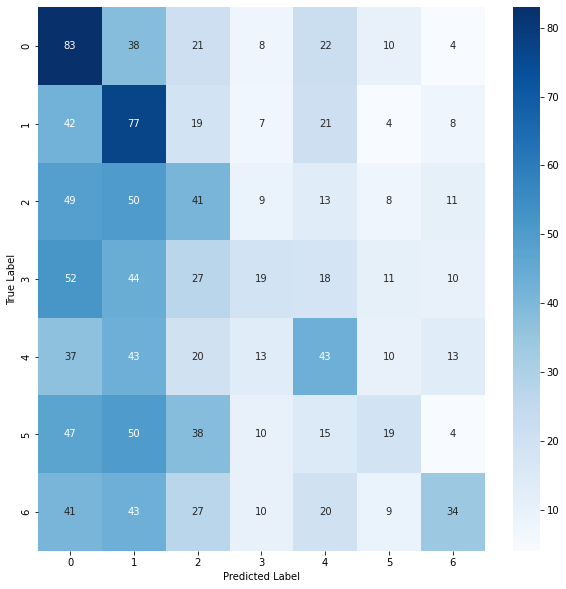

In [8]:
# create confusion matrix using y_pred and test_label_list by predict rate and show with heatmap
def show_with_heapmap(y_pred, test_label_list):
    # create confusion matrix using y_pred and test_label_list by predict rate
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(test_label_list, y_pred)

    # show confusion matrix with heatmap
    plt.figure(figsize=(10, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()


show_with_heapmap(y_pred, test_label_list)

0.45 0.20 0.11 0.04 0.12 0.05 0.02 
0.24 0.43 0.11 0.04 0.12 0.02 0.04 
0.27 0.28 0.23 0.05 0.07 0.04 0.06 
0.29 0.24 0.15 0.10 0.10 0.06 0.06 
0.21 0.24 0.11 0.07 0.24 0.06 0.07 
0.26 0.27 0.21 0.05 0.08 0.10 0.02 
0.22 0.23 0.15 0.05 0.11 0.05 0.18 


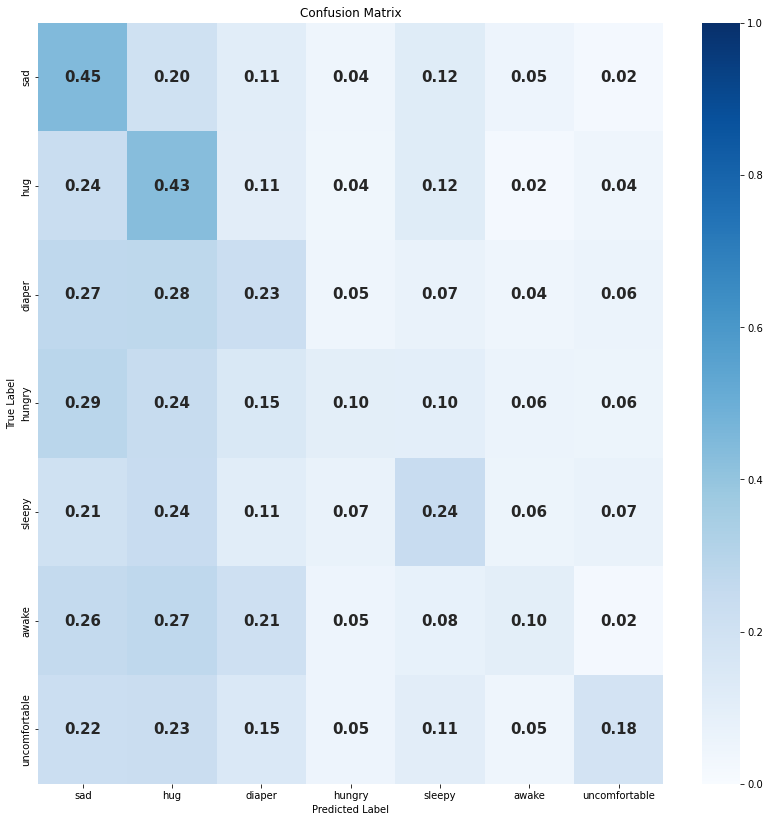

In [20]:
from sklearn.metrics import confusion_matrix

confusion_mat = confusion_matrix(test_label_list, y_pred)
class_labels = label_list

# 정규화된 Confusion Matrix 계산
cm_normalized = confusion_mat.astype(
    'float') / confusion_mat.sum(axis=1)[:, np.newaxis]

for i in range(7):
    for j in range(7):
        print(f'{cm_normalized[i][j]:.2f}', end=' ')
    print()


def show_with_heapmap(cm, class_labels):
    # show confusion matrix with heatmap
    plt.figure(figsize=(14, 14))
    heatmap = sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                          xticklabels=class_labels, yticklabels=class_labels, vmin=0, vmax=1, annot_kws={'size': 15, 'weight': 'bold'})

    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()


show_with_heapmap(cm_normalized, state_list)